# Anfang
## Daten einlesen

In [1]:
import pandas as pd

path_processed_data = '../Data/Processed/'
time_series = pd.read_csv(path_processed_data + 'cleaned_timeseries.csv')

# Format der Spalte Datum richten
time_series['date'] = pd.to_datetime(time_series['date'])

# Datum in Index bringen
time_series.set_index('date', inplace=True)

# SOnst wissen Modelle später nicht, das Daten auf täglicher Basis
time_series.index.freq = 'D'

print(time_series.head(4))
print()
print(time_series.info())

            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0

<class 'pandas.DataFrame'>
DatetimeIndex: 454 entries, 2013-01-02 to 2014-03-31
Freq: D
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unit_sales  454 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB
None


## Splitten in Trainings- und Testdaten

In [2]:
train_data = time_series.loc["2013-01-01":"2013-12-31"]
test_data  = time_series.loc["2014-01-01":"2014-03-31"]

print(train_data.tail(4))
print()
print(test_data.head(4))

            unit_sales
date                  
2013-12-28       499.0
2013-12-29       552.0
2013-12-30       595.0
2013-12-31       436.0

            unit_sales
date                  
2014-01-01       436.0
2014-01-02       589.0
2014-01-03       474.0
2014-01-04       767.0


# ARIMA
## ADF-Test

In [3]:
from statsmodels.tsa.stattools import adfuller

# adfuller() funktioniert nicht direkt mit Darts TimeSeries –
# wir müssen die Werte extrahieren:
arr = train_data.values.flatten()

result = adfuller(arr)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"ADF p-value: {result[1]:.2e}")
print(f"Critical Values: {result[4]}")

ADF Statistic: -4.2188
ADF p-value: 6.12e-04
Critical Values: {'1%': np.float64(-3.4492815848836296), '5%': np.float64(-2.8698813715275406), '10%': np.float64(-2.5712138845950587)}


- => p-Wert deutlich unter 0.05 => Daten im Sinne der Einheitswurzel stationär

## Pandas Dataframe -> Time.Series Format

In [4]:
from darts import TimeSeries

train_data_ts = TimeSeries.from_dataframe(train_data, value_cols='unit_sales')
test_data_ts = TimeSeries.from_dataframe(test_data, value_cols='unit_sales')

## Model building

In [5]:
# ARIMA aus der Bibliothek darts importieren
from darts.models import ARIMA

# ARIMA-Modell mit (p, d, q) Parametern initialisieren
#arima_model = ARIMA(p=7, d=0, q=1)  # ARIMA(p, d, q)
# !!!! Diese zufällig gewählten Parameter sind deutlich besser als die oben ewig hergeleiteten!!!
arima_model = ARIMA(p=3, d=0, q=3)  # ARIMA(p, d, q)

# ARIMA-Modell mit den Trainingsdaten fitten
arima_model = arima_model.fit(train_data_ts)

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
/opt/miniconda3/envs/work/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximu

## Forecast

In [6]:
# Vorhersage für den Zeitraum der Testdaten (90 Tage = len(test))
arima_forecast = arima_model.predict(len(test_data_ts))

## Plotting

<Axes: xlabel='date'>

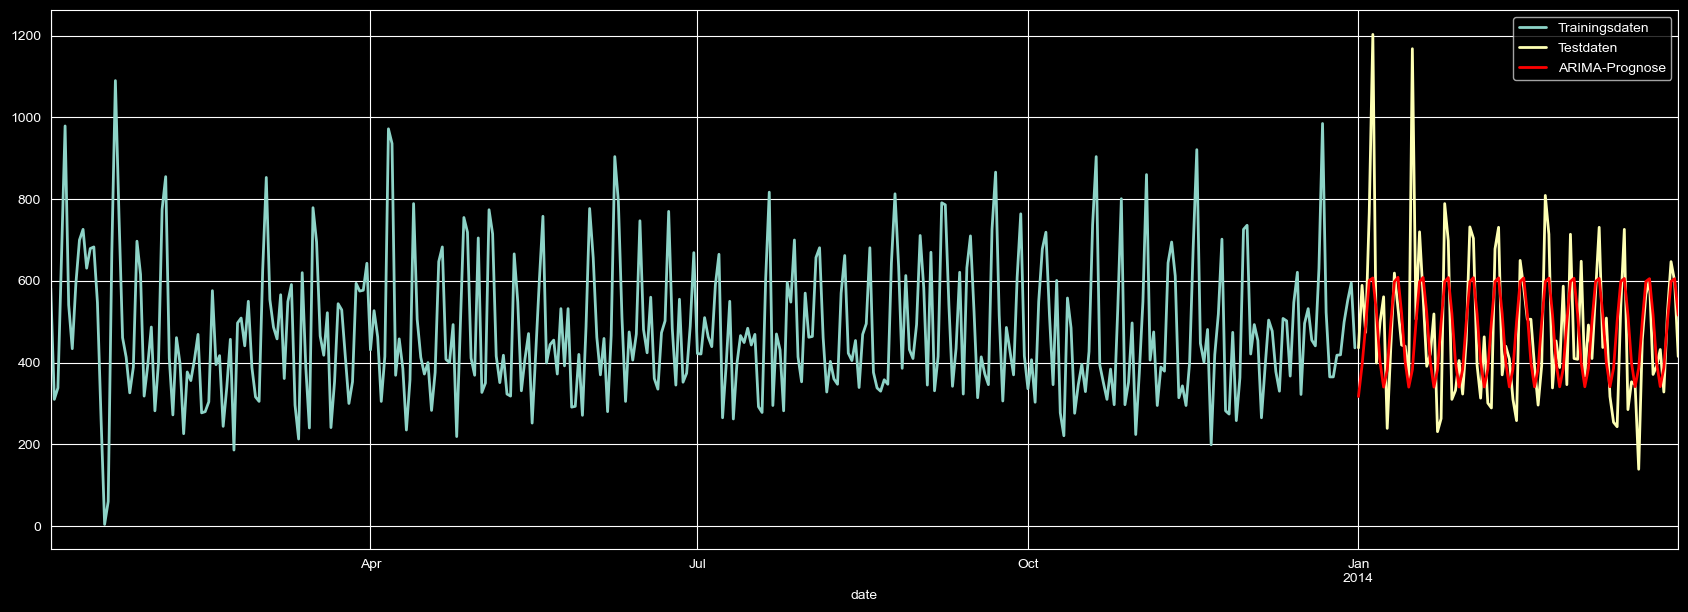

In [7]:
import matplotlib.pyplot as plt

# Prognose (rot) mit tatsächlichen Daten (blau) vergleichen
plt.figure(figsize=(21, 7))  # Größe der Grafik einstellen (Breite, Höhe)
train_data_ts.plot(label='Trainingsdaten')
test_data_ts.plot(label='Testdaten')
arima_forecast.plot(label='ARIMA-Prognose', color='red')

## Evaluierung

In [8]:
print(test_data.shape)
print(arima_forecast.shape)

(90, 1)
(90, 1, 1)


=> beides sind 3D-Darts TimeSeries-Objekte und müssen umgewandelt werden in 1D-Array

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# (1) AIC und BIC
aic = arima_model.model.aic
bic = arima_model.model.bic

print(f"ARIMA AIC: {aic:.2f}")
print(f"ARIMA BIC: {bic:.2f}")

# (2) MAE und RMSE
# (2a) Formate anpassen
## .values() => Extrahiert die rohen Zahlen aus dem Darts TimeSeries-Objekt als NumPy-Array – aber in 3D-Form
## .flatten() => Macht daraus ein 1D-Array, das sklearn verarbeiten kann
actual = test_data_ts.values().flatten()
arima_forecast_arr = arima_forecast.values().flatten()

mae = mean_absolute_error(actual, arima_forecast_arr)
rmse = np.sqrt(mean_squared_error(actual, arima_forecast_arr))

print(f"ARIMA MAE: {mae:.2f}")
print(f"ARIMA RMSE: {rmse:.2f}")

ARIMA AIC: 4610.83
ARIMA BIC: 4642.00
ARIMA MAE: 114.74
ARIMA RMSE: 159.38


# SARIMA
## Model building

In [10]:
from darts.models import ARIMA

# Initialize ARIMA model with both (p, d, q) and (P, D, Q, m) parameters
sarima_model = ARIMA(p=3, d=0, q=3, seasonal_order=(1, 1, 1, 7))

# Fit the ARIMA model with seasonality on the training data
sarima_model.fit(train_data_ts)

/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(p=3, d=0, q=3, seasonal_order=(1, 1, 1, 7), trend=None, random_state=None, add_encoders=None)

## Forecast

In [11]:
# Forecast the next values (the same length as the test set)
sarima_forecast = sarima_model.predict(len(test_data_ts))

## Plotting

<Axes: xlabel='date'>

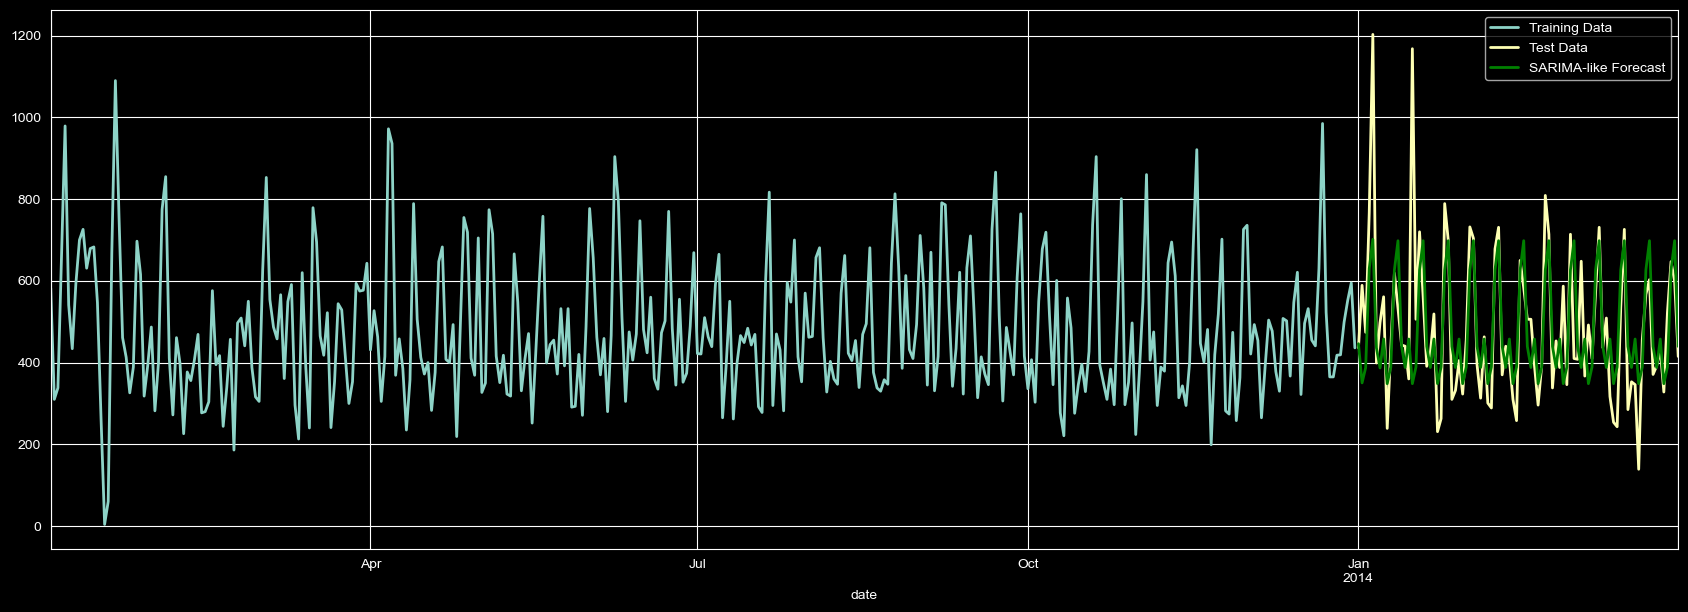

In [12]:
# Plot SARIMA-like forecast vs actual data
plt.figure(figsize=(21, 7))  # Adjust the figure size (width, height)
train_data_ts.plot(label='Training Data')
test_data_ts.plot(label='Test Data')
sarima_forecast.plot(label='SARIMA-like Forecast', color='green')

## Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# (1) AIC und BIC
aic = sarima_model.model.aic
bic = sarima_model.model.bic

print(f"SARIMA AIC: {aic:.2f}")
print(f"SARIMA BIC: {bic:.2f}")

# (2) MAE und RMSE
# (2a) Formate anpassen
## .values() => Extrahiert die rohen Zahlen aus dem Darts TimeSeries-Objekt als NumPy-Array – aber in 3D-Form
## .flatten() => Macht daraus ein 1D-Array, das sklearn verarbeiten kann
actual = test_data_ts.values().flatten()
sarima_forecast_arr = sarima_forecast.values().flatten()

mae = mean_absolute_error(actual, sarima_forecast_arr)
rmse = np.sqrt(mean_squared_error(actual, sarima_forecast_arr))

print(f"SARIMA MAE: {mae:.2f}")
print(f"SARIMA RMSE: {rmse:.2f}")

SARIMA AIC: 4418.00
SARIMA BIC: 4452.90
SARIMA MAE: 94.29
SARIMA RMSE: 142.63


# Single, Double and Triple Exponential Smoothing (ES)
## Fit models and generate forecasts

In [14]:
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
import matplotlib.pyplot as plt

forecast_horizon = 90  # Forecast next 12 points

# Simple Exponential Smoothing
#simple_model = SimpleExpSmoothing(train_data).fit()
simple_model = SimpleExpSmoothing(train_data['unit_sales']).fit()
simple_fitted = simple_model.fittedvalues
simple_forecast = simple_model.forecast(forecast_horizon)

# Double Exponential Smoothing (Holt)
#double_model = Holt(train_data).fit()
double_model = Holt(train_data['unit_sales']).fit()
double_fitted = double_model.fittedvalues
double_forecast = double_model.forecast(forecast_horizon)

# Triple Exponential Smoothing (Holt-Winters)
#triple_model = ExponentialSmoothing(train_data, seasonal_periods=12, trend='add', seasonal='add').fit()
triple_model = ExponentialSmoothing(
    train_data['unit_sales'],
    seasonal_periods=7,
    trend='add',    # -> additives Model
    seasonal='add'  # -> additives Model
).fit()

triple_fitted = triple_model.fittedvalues
triple_forecast = triple_model.forecast(forecast_horizon)

In [15]:
simple_forecast.head(4)

2014-01-01    480.765552
2014-01-02    480.765552
2014-01-03    480.765552
2014-01-04    480.765552
Freq: D, dtype: float64

## Plotting

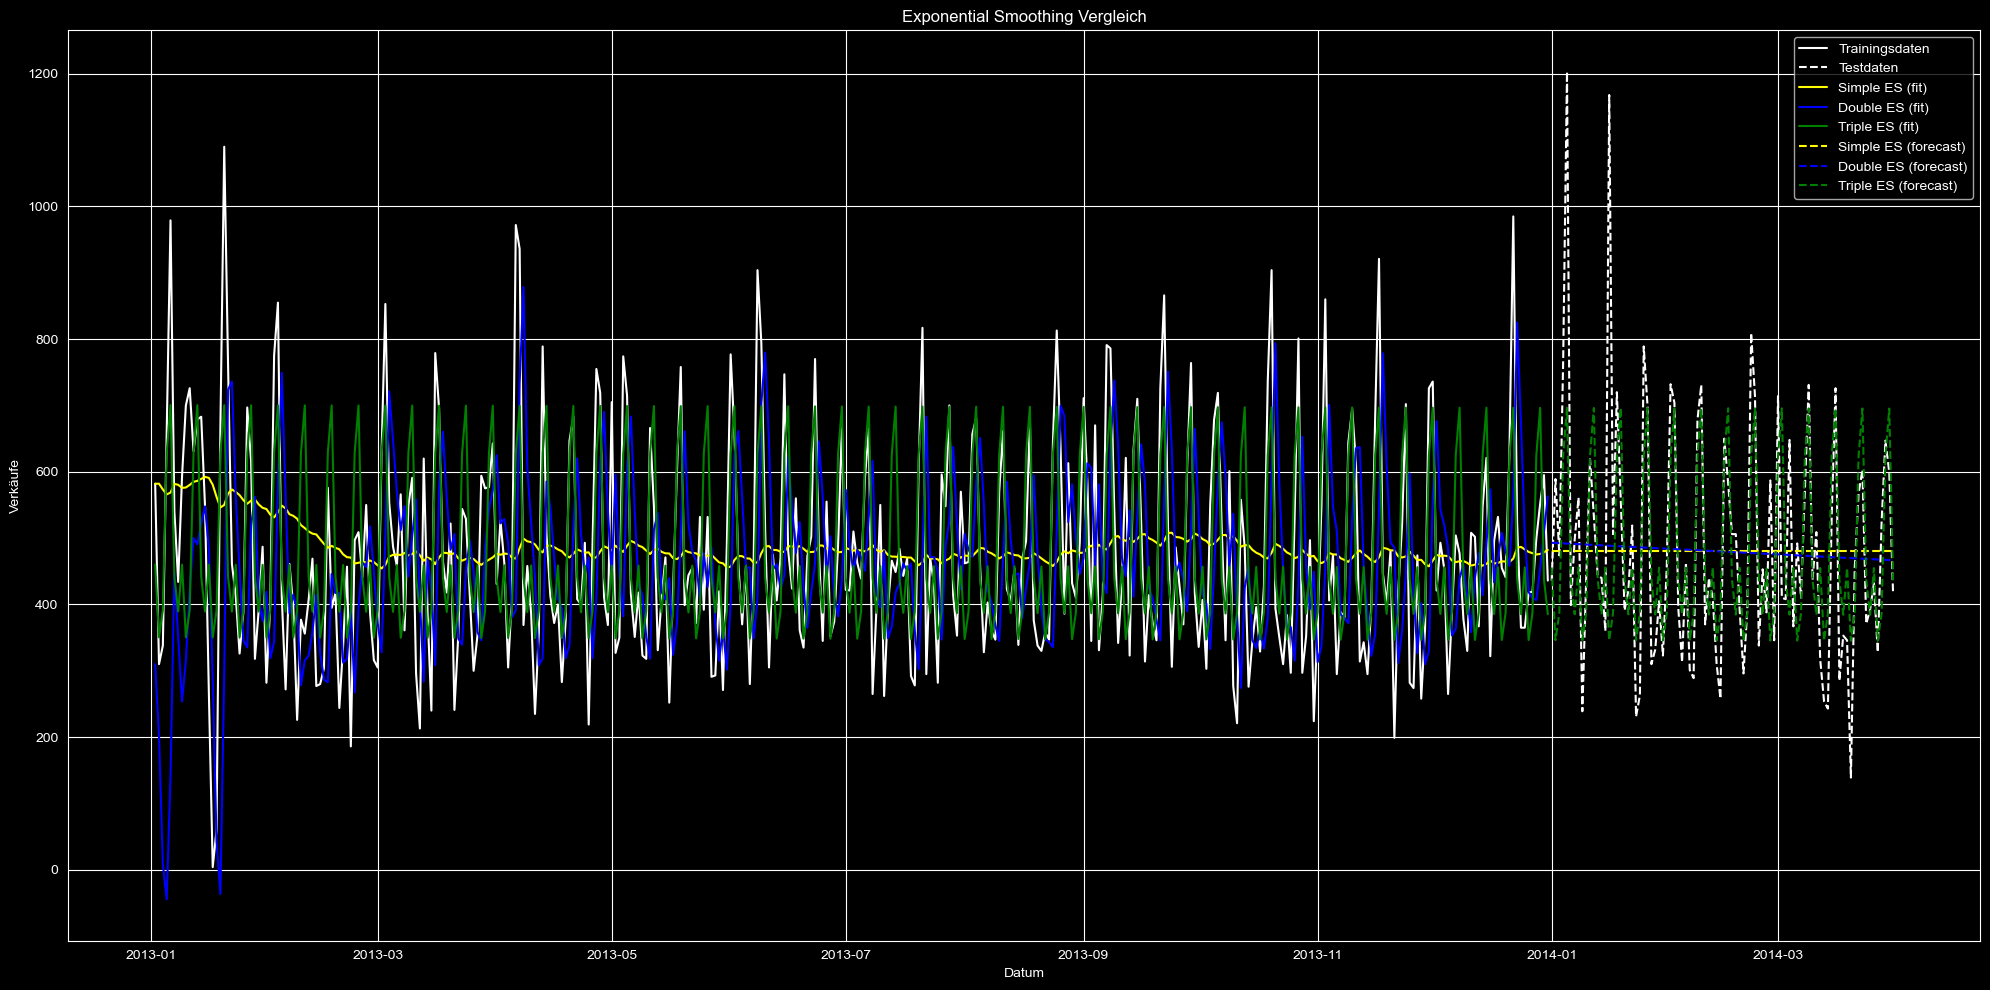

In [16]:
plt.figure(figsize=(20, 10))

# Trainingsdaten
plt.plot(train_data.index, train_data, label='Trainingsdaten', color='white')

# Testdaten
plt.plot(test_data.index, test_data, label='Testdaten', color='white', linestyle='--')

# Gefittete Werte (auf Trainingsdaten)
plt.plot(train_data.index, simple_fitted, label='Simple ES (fit)', color='yellow', linestyle='-')
plt.plot(train_data.index, double_fitted, label='Double ES (fit)', color='blue', linestyle='-')
plt.plot(train_data.index, triple_fitted, label='Triple ES (fit)', color='green', linestyle='-')

# Forecasts (auf Testzeitraum)
plt.plot(simple_forecast.index, simple_forecast, label='Simple ES (forecast)', color='yellow', linestyle='--')
plt.plot(double_forecast.index, double_forecast, label='Double ES (forecast)', color='blue', linestyle='--')
plt.plot(triple_forecast.index, triple_forecast, label='Triple ES (forecast)', color='green', linestyle='--')

plt.legend()
plt.title('Exponential Smoothing Vergleich')
plt.xlabel('Datum')
plt.ylabel('Verkäufe')
plt.tight_layout()
plt.show()

## Evaluierung

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Forecast-Werte auf Testzeitraum zuschneiden
simple_pred = simple_forecast[:len(test_data)]
double_pred = double_forecast[:len(test_data)]
triple_pred = triple_forecast[:len(test_data)]

actual = test_data['unit_sales'].values

# MAE
print(f"Simple ES  MAE: {mean_absolute_error(actual, simple_pred):.2f}")
print(f"Double ES  MAE: {mean_absolute_error(actual, double_pred):.2f}")
print(f"Triple ES  MAE: {mean_absolute_error(actual, triple_pred):.2f}")
print()

# RMSE
print(f"Simple ES  RMSE: {np.sqrt(mean_squared_error(actual, simple_pred)):.2f}")
print(f"Double ES  RMSE: {np.sqrt(mean_squared_error(actual, double_pred)):.2f}")
print(f"Triple ES  RMSE: {np.sqrt(mean_squared_error(actual, triple_pred)):.2f}")
print()

# AIC
print(f"Simple ES  AIC: {simple_model.aic:.1f}")
print(f"Double ES  AIC: {double_model.aic:.1f}")
print(f"Triple ES  AIC: {triple_model.aic:.1f}")
print()

# BIC
print(f"Simple ES  BIC: {simple_model.bic:.1f}")
print(f"Double ES  BIC: {double_model.bic:.1f}")
print(f"Triple ES  BIC: {triple_model.bic:.1f}")

Simple ES  MAE: 140.55
Double ES  MAE: 139.95
Triple ES  MAE: 94.37

Simple ES  RMSE: 183.53
Double ES  RMSE: 182.33
Triple ES  RMSE: 142.95

Simple ES  AIC: 3741.7
Double ES  AIC: 3893.6
Triple ES  AIC: 3464.6

Simple ES  BIC: 3749.5
Double ES  BIC: 3909.2
Triple ES  BIC: 3507.5


## Interpretation

- Triple ES gewinnt klar – konsistent bestes Ergebnis auf allen Metriken.
- Auffällig: Double ES ist schlechter als Simple ES. Das macht intuitiv Sinn: Die Daten haben keinen Trend – Double ES modelliert aber einen.
- RMSE deutlich größer als MAE → das Modell hat einige größere Ausreißerfehler. Im Schnitt liegt es 98 daneben, aber einzelne Tage weicht es stärker ab
-
- INTERESSANT:
- SARIMA erfordert ewiges herumgeschraube an Parametern, während Triple ES einfach läuft
- hatte MAE = 97.65 – also praktisch identisch mit Triple ES (98.43). Triple ES erreicht also mit viel weniger Aufwand dasselbe Ergebnis
- SARIMA vs Triple exponential Smoothing:
    - Triple ES → einfacher, schneller, robuster als SARMIA
    - SARIMA → flexibler, interpretierbarer, kann komplexere Autokorrelationsstrukturen abbilden
    - => In der Praxis gilt oft: Triple ES als starke Baseline, SARIMA wenn man mehr Kontrolle oder bessere Ergebnisse braucht.

# Prophet
## Format der Time-Series anpassen

In [18]:
from prophet import Prophet
import pandas as pd
from statsmodels.datasets import get_rdataset
import matplotlib.pyplot as plt

In [19]:
# Ich habe in der Zeitreihe das Datum in den Index geschoben
# Dieses Format passt fürs Prophet Modell nicht
# => folgende Anpassung nötig:
train_df = train_data_ts.to_dataframe().reset_index()
train_df.columns = ['ds', 'y']

print(train_data_ts.head(4))
print()
print(train_df.head(4))

            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0

shape: (4, 1, 1), freq: D, size: 32.00 B

          ds      y
0 2013-01-02  582.0
1 2013-01-03  310.0
2 2013-01-04  338.0
3 2013-01-05  654.0


## Model building

In [20]:
# Initialize the model
model = Prophet(seasonality_mode='additive')    #seasonality_mode='multiplicative'

# Fit the model
model.fit(train_df)

print("Model fitted successfully!")

15:43:27 - cmdstanpy - INFO - Chain [1] start processing
15:43:27 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully!


## Forecast

In [21]:
# Create future dataframe for predictions
future = model.make_future_dataframe(periods=len(test_data), freq='D')
forecast = model.predict(future)

# Make predictions
forecast = model.predict(future)

print("Forecast columns:")
print(forecast.columns.tolist())

Forecast columns:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']


In [22]:
forecast.head(4)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-02,486.421961,323.071438,610.784901,486.421961,486.421961,-20.251396,-20.251396,-20.251396,-20.251396,-20.251396,-20.251396,0.0,0.0,0.0,466.170565
1,2013-01-03,486.285183,205.425682,494.204027,486.285183,486.285183,-129.818248,-129.818248,-129.818248,-129.818248,-129.818248,-129.818248,0.0,0.0,0.0,356.466934
2,2013-01-04,486.148404,254.400393,543.317441,486.148404,486.148404,-89.005033,-89.005033,-89.005033,-89.005033,-89.005033,-89.005033,0.0,0.0,0.0,397.143371
3,2013-01-05,486.011625,494.965045,771.028964,486.011625,486.011625,148.453686,148.453686,148.453686,148.453686,148.453686,148.453686,0.0,0.0,0.0,634.465312


In [23]:
forecast.tail(4)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
450,2014-03-28,474.247861,239.972307,537.276740,473.268352,475.243971,-89.005033,-89.005033,-89.005033,-89.005033,-89.005033,-89.005033,0.0,0.0,0.0,385.242828
451,2014-03-29,474.233491,480.165388,764.068785,473.237440,475.247565,148.453686,148.453686,148.453686,148.453686,148.453686,148.453686,0.0,0.0,0.0,622.687177
452,2014-03-30,474.219121,553.908446,835.205439,473.200956,475.251159,220.051044,220.051044,220.051044,220.051044,220.051044,220.051044,0.0,0.0,0.0,694.270166
453,2014-03-31,474.204752,294.500497,580.816197,473.173143,475.254752,-38.438373,-38.438373,-38.438373,-38.438373,-38.438373,-38.438373,0.0,0.0,0.0,435.766379


## Plotting

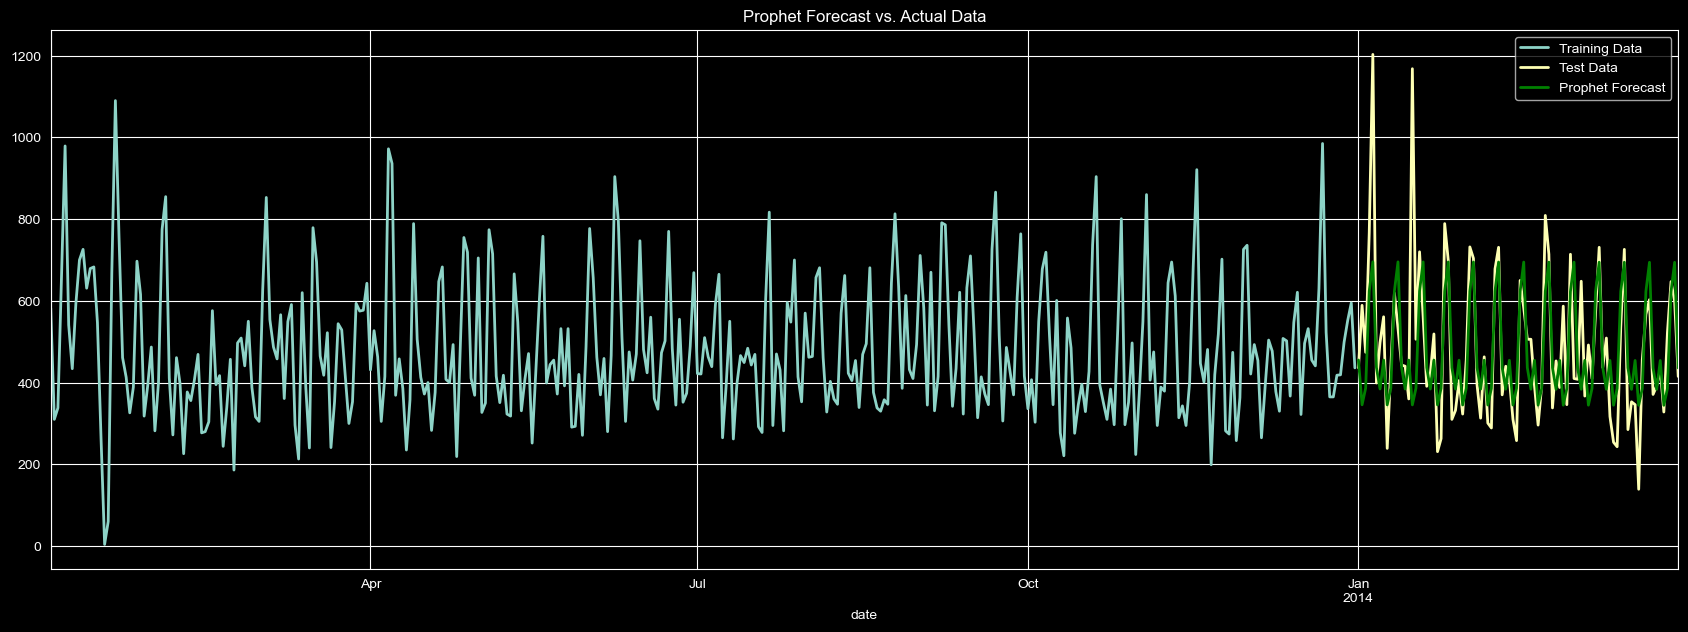

In [24]:
from darts import TimeSeries

# Split: Fitted (2013) vs Forecast (2014)
last_train_date = train_df['ds'].max()
forecast_future = forecast[forecast['ds'] > last_train_date]

# Prophet Forecast → Darts TimeSeries
forecast_ts = TimeSeries.from_dataframe(
    forecast_future[['ds', 'yhat']].rename(columns={'ds': 'date', 'yhat': 'unit_sales'}),
    time_col='date',
    value_cols='unit_sales'
)

# Plot
plt.figure(figsize=(21, 7))
train_data_ts.plot(label='Training Data')
test_data_ts.plot(label='Test Data')
forecast_ts.plot(label='Prophet Forecast', color='green')
plt.title('Prophet Forecast vs. Actual Data')
plt.legend()
plt.show()

## Evaluierung

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Formate anpassen
actual           = test_data_ts.values().flatten()
prophet_forecast_arr = forecast_ts.values().flatten()

mae  = mean_absolute_error(actual, prophet_forecast_arr)
rmse = np.sqrt(mean_squared_error(actual, prophet_forecast_arr))

print(f"Prophet MAE:  {mae:.2f}")
print(f"Prophet RMSE: {rmse:.2f}")
print("Prophet AIC:  nicht verfügbar in Prophet")
print("Prophet BIC:  nicht verfügbar in Prophet")

Prophet MAE:  94.35
Prophet RMSE: 142.99
Prophet AIC:  nicht verfügbar in Prophet
Prophet BIC:  nicht verfügbar in Prophet
